# 4. Interpolazione spaziale
Interpolazione spaziale del valore medio annuale di NO2 sull'intera superficie regionale a partire dai valori puntuali delle stazioni, con due metodi a confronto: **IDW** (Inverse Distance Weighting) e **Spline**.

In [ ]:
import geopandas as gpd
import h3pandas
from shapely.geometry import Point, Polygon
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Importazione e pulizia dati

In [2]:
#importazione dati
dati = pd.read_csv("/Users/giulia/Documents/geopandas/Air-quality-Lombardy-2025/data/Dati_sensori_aria_2025.csv")
stazioni = gpd.read_file("/Users/giulia/Documents/geopandas/Air-quality-Lombardy-2025/data/Stazioni qualità dell aria_20260826/geo_export_1e1f2c5a-263d-4a72-908d-7477842f54c0.shp")
province = gpd.read_file("/Users/giulia/Documents/geopandas/Air-quality-Lombardy-2025/data/Limiti amministrativi Province 2020 con aggiornamenti DbT_PGT_20260826/geo_export_97ffb683-dd2e-40cd-b28e-c03e599be95f.shp")

In [3]:
#pulizia dati di qualità dell'aria, delle stazioni e delle province
import functions as f
dati_puliti = f.pulizia_dati(dati)
stazioni_pulite = f.pulizia_stazioni(stazioni)
province = province.to_crs("EPSG:7791")
province = province.rename(columns={'sigla': 'provincia'})

# Media giornaliera  e annuale per sensore

In [4]:
#calcolo della media giornaliera per sensore
dati_giornalieri = dati_puliti.groupby(["idsensore", dati_puliti["Data"].dt.date])["Valore"].mean().reset_index()
dati_giornalieri.columns = ["idsensore", "Data", "Valore_medio"]

In [6]:
#media annuale
dati_medi = (dati_giornalieri.groupby(['idsensore'])['Valore_medio'].mean().reset_index())

# Merge stazioni e dati

In [8]:
#merge stazioni e dati 
dati_medi_stazioni = pd.merge(
    dati_medi, stazioni_pulite, on='idsensore', how='left'
)

In [9]:
#Conversione in un GeoDataFrame
dati_medi_stazioni = gpd.GeoDataFrame(dati_medi_stazioni, geometry='geometry', crs=stazioni_pulite.crs)

# Selezione dell'inquinante da considerare in base alla sua copertura

In [15]:
#pivot table
df_pivot = dati_medi_stazioni.pivot(index="idstazione", columns="inquinante", values="Valore_medio")
df_pivot.drop(columns=[np.nan], errors='ignore')

inquinante,Ammoniaca,Arsenico,Benzene,Benzo(a)pirene,Biossido di Azoto,Biossido di Zolfo,Cadmio,Monossido di Carbonio,Nikel,Ossidi di Azoto,Ozono,PM10 (SM2005),Particelle sospese PM2.5,Piombo
idstazione,,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
501.0,NaN,NaN,NaN,NaN,38.120167,NaN,NaN,0.878491,NaN,76.895181,NaN,NaN,NaN,NaN
504.0,NaN,NaN,NaN,NaN,35.292870,NaN,NaN,0.391281,NaN,66.769282,NaN,NaN,NaN,NaN
514.0,NaN,NaN,NaN,NaN,32.668706,NaN,NaN,NaN,NaN,66.676581,NaN,NaN,NaN,NaN
517.0,NaN,NaN,NaN,NaN,16.575747,NaN,NaN,NaN,NaN,24.496134,NaN,22.519663,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1265.0,NaN,NaN,NaN,NaN,21.562068,NaN,NaN,NaN,NaN,32.513731,47.976415,28.461318,21.431034,NaN
1266.0,34.687383,NaN,NaN,NaN,17.019089,NaN,NaN,NaN,NaN,23.748267,47.234897,27.318841,NaN,NaN
1269.0,NaN,NaN,0.62985,NaN,20.415575,NaN,NaN,0.588227,NaN,28.651131,NaN,24.684685,17.444776,NaN


In [16]:
df_pivot.notna().sum().sort_values(ascending=False)

inquinante
Biossido di Azoto           78
Ossidi di Azoto             77
PM10 (SM2005)               56
Ozono                       40
Monossido di Carbonio       25
Particelle sospese PM2.5    25
Biossido di Zolfo           21
Benzene                     16
Cadmio                      13
Benzo(a)pirene              13
Arsenico                    13
Nikel                       13
Piombo                      13
Ammoniaca                    3
NaN                          1
dtype: int64

Il Biossido di Azoto è l'inquinante con più misurazioni

In [18]:
NO2_medio_stazioni = dati_medi_stazioni[dati_medi_stazioni['inquinante']=='Biossido di Azoto']

In [19]:
NO2_medio_stazioni.explore()

Le misurazioni di Biossido di Azoto hanno una buona copertura spaziale.

# Creazione di due dataset: uno per il modello e uno di controllo

In [20]:
#salvataggio coordinate dei punti (x=longitudine, y=latitudine, z=valore medio NO2)
NO2_medio_stazioni = NO2_medio_stazioni[['idstazione', 'Valore_medio', 'lat', 'lng']].dropna()

x = NO2_medio_stazioni['lng'].values
y = NO2_medio_stazioni['lat'].values
z = NO2_medio_stazioni['Valore_medio'].values

In [ ]:
#Split punti di modello / punti di controllo
idx = np.arange(len(NO2_medio_stazioni))
idx_model, idx_control = train_test_split(idx, test_size=0.2, random_state=42)


In [23]:
x_model, y_model, z_model = x[idx_model], y[idx_model], z[idx_model]
x_control, y_control, z_control = x[idx_control], y[idx_control], z[idx_control]

# Interpolazione IDW

Funzione che calcola la media pesata dei valori campionati nei punti all’interno della finestra mobile. Il peso è funzione della distanza tra il punto di misura e il punto del modello. Maggiore è la distanza, minore sarà il peso assegnato al valore misurato.
Il peso può essere scelto come l’inverso della distanza o l’inverso del quadrato della distanza. 

In [24]:
#bounding box del confine regionale
province = gpd.read_file("/Users/giulia/Documents/geopandas/progetto_qualita_aria_Lombardia/Limiti amministrativi Province 2020 con aggiornamenti DbT_PGT_20260826/geo_export_97ffb683-dd2e-40cd-b28e-c03e599be95f.shp")
minx, miny, maxx, maxy = province.total_bounds

grid_x, grid_y = np.meshgrid(
    np.linspace(minx, maxx, 300),   
    np.linspace(miny, maxy, 300)
)

In [25]:
def idw_interpolation(x_model, y_model, z_model, x_target, y_target, power=2):
    
    x_target = np.atleast_1d(x_target)
    y_target = np.atleast_1d(y_target)
    z_pred = np.zeros(len(x_target))

    for i in range(len(x_target)):
        dist = np.sqrt((x_model - x_target[i])**2 + (y_model - y_target[i])**2)
        
        # se il punto target coincide esattamente con un punto di modello, usa quel valore
        if np.any(dist == 0):
            z_pred[i] = z_model[dist == 0][0]
            continue
        
        weights = 1 / dist**power
        z_pred[i] = np.sum(weights * z_model) / np.sum(weights)

    return z_pred

In [26]:
#interpolazione su griglia regolare (300x300 punti sull'estensione della Lombardia)
grid_x, grid_y = np.meshgrid(
    np.linspace(minx, maxx, 300),
    np.linspace(miny, maxy, 300)
)

z_grid_idw = idw_interpolation(
    x_model, y_model, z_model,
    grid_x.ravel(), grid_y.ravel(),
    power=2
).reshape(grid_x.shape)


In [27]:
#predizione sui punti di controllo, per validare il modello
z_pred_idw_control = idw_interpolation(x_model, y_model, z_model, x_control, y_control, power=2)

# Interpolazione Spline bicubica

Il modello è dato da un polinomio di terzo grado che interpola localmente i dati misurati, usando un numero limitato di dati in input all’interno di una finestra mobile. Le Spline sono interpolatori “esatti”, cioè la funzione interpolante passa per i punti misurati.

In [28]:
from scipy.interpolate import Rbf
rbf_spline = Rbf(x_model, y_model, z_model, function='thin_plate')

z_grid_spline = rbf_spline(grid_x, grid_y)

z_pred_spline_control = rbf_spline(x_control, y_control)

# Confronto tra i metodi di interpolazione

In [29]:
#calcolo dell'errore sui punti di controllo (errore medio, RMSE, min, max)

def calcola_errori(z_osservato, z_stimato, nome_metodo):
    errori = np.abs(z_osservato - z_stimato)
    return {
        'metodo': nome_metodo,
        'errore_medio': errori.mean(),
        'rmse': np.sqrt(np.mean((z_osservato - z_stimato)**2)),
        'errore_min': errori.min(),
        'errore_max': errori.max()
    }

errori_idw = calcola_errori(z_control, z_pred_idw_control, 'IDW')
errori_spline = calcola_errori(z_control, z_pred_spline_control, 'Spline')

tabella_errori = pd.DataFrame([errori_idw, errori_spline])
print(tabella_errori)

   metodo  errore_medio      rmse  errore_min  errore_max
0     IDW      4.555992  5.265061    0.341909    9.947313
1  Spline      5.028130  6.223818    0.948394   13.385615


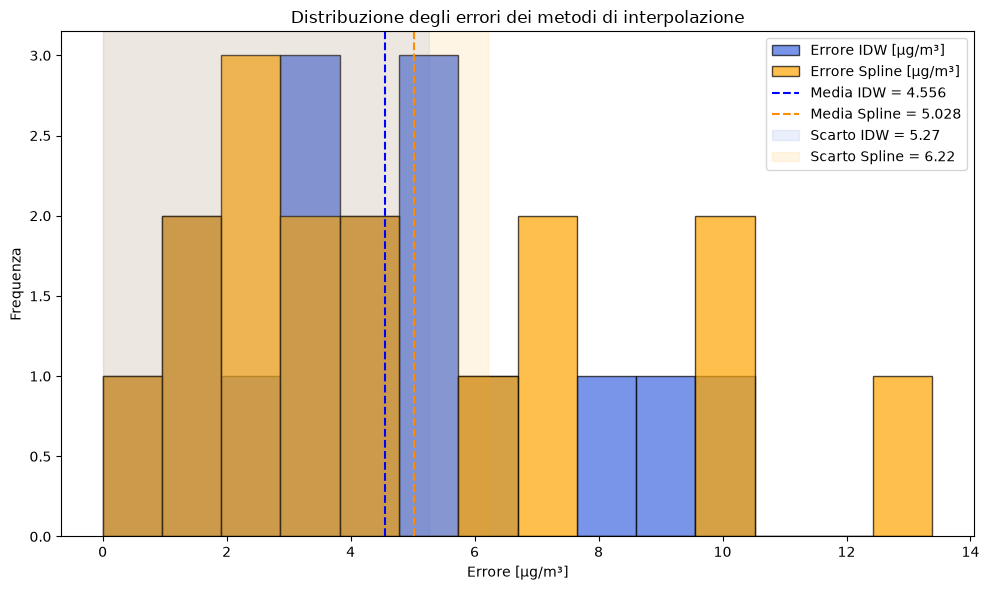

In [ ]:
# errori assoluti sui punti di controllo (già calcolati prima)
errori_idw = np.abs(z_control - z_pred_idw_control)
errori_spline = np.abs(z_control - z_pred_spline_control)

media_idw = errori_idw.mean()
media_spline = errori_spline.mean()
scarto_idw = np.sqrt(np.mean((z_control - z_pred_idw_control)**2))    # RMSE
scarto_spline = np.sqrt(np.mean((z_control - z_pred_spline_control)**2))

fig, ax = plt.subplots(figsize=(10, 6))

# bin comuni per confrontare le due distribuzioni sulla stessa scala
bin_max = max(errori_idw.max(), errori_spline.max())
bins = np.linspace(0, bin_max, 15)

ax.hist(errori_idw, bins=bins, alpha=0.7, color='royalblue', label='Errore IDW [µg/m³]', edgecolor='black')
ax.hist(errori_spline, bins=bins, alpha=0.7, color='orange', label='Errore Spline [µg/m³]', edgecolor='black')

# linee verticali per le medie
ax.axvline(media_idw, color='blue', linestyle='--', linewidth=1.5, label=f'Media IDW = {media_idw:.3f}')
ax.axvline(media_spline, color='darkorange', linestyle='--', linewidth=1.5, label=f'Media Spline = {media_spline:.3f}')

# fasce ombreggiate per lo scarto quadratico medio (RMSE), come nel report
ax.axvspan(0, scarto_idw, color='royalblue', alpha=0.1, label=f'Scarto IDW = {scarto_idw:.2f}')
ax.axvspan(0, scarto_spline, color='orange', alpha=0.1, label=f'Scarto Spline = {scarto_spline:.2f}')

ax.set_xlabel('Errore [µg/m³]')
ax.set_ylabel('Frequenza')
ax.set_title('Distribuzione degli errori dei metodi di interpolazione')
ax.legend()

plt.tight_layout()
plt.show()

# Mappe delle interpolazioni spaziali con i due metodi

In [31]:
#unione di tutte le geometrie provinciali in un unico poligono (confine regionale)
confine_lombardia = province.union_all()

In [32]:
from shapely.vectorized import contains

dentro_confine = contains(confine_lombardia, grid_x, grid_y)

z_grid_idw_masked = np.where(dentro_confine, z_grid_idw, np.nan)
z_grid_spline_masked = np.where(dentro_confine, z_grid_spline, np.nan)

/var/folders/v_/kk7j95gj68dd40z9kpnmmr3h0000gn/T/ipykernel_4324/3891009511.py:3: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  dentro_confine = contains(confine_lombardia, grid_x, grid_y)


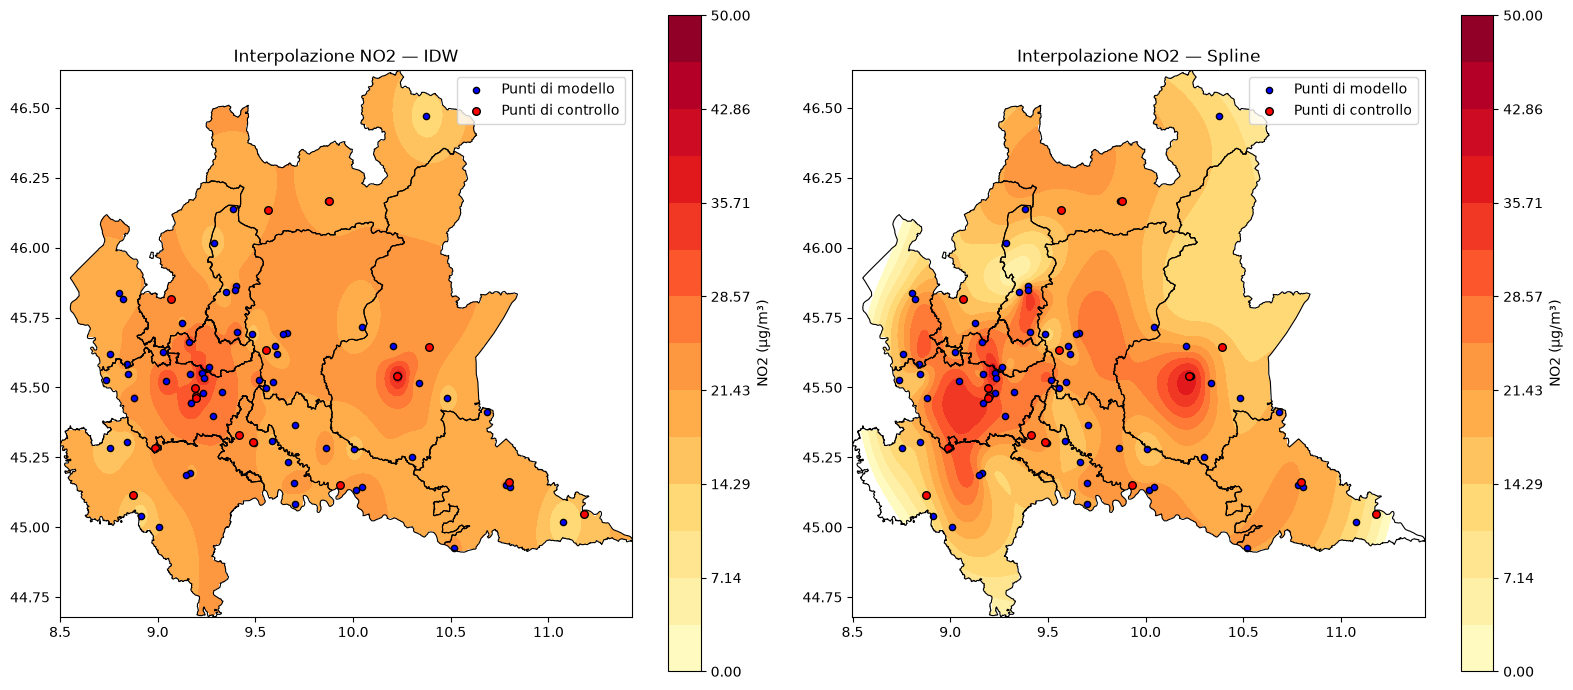

In [34]:
vmin, vmax = 0, 50  # range fisicamente plausibile per NO2
livelli = np.linspace(vmin, vmax, 15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, z_grid, titolo in zip(axes, [z_grid_idw_masked, z_grid_spline_masked], ['IDW', 'Spline']):
    c = ax.contourf(grid_x, grid_y, z_grid, levels=livelli, vmin=vmin, vmax=vmax, cmap='YlOrRd')
    province.boundary.plot(ax=ax, color='black', linewidth=0.8)
    ax.scatter(x_model, y_model, c='blue', s=20, label='Punti di modello', edgecolor='black')
    ax.scatter(x_control, y_control, c='red', s=30, label='Punti di controllo', edgecolor='black')
    ax.set_title(f'Interpolazione NO2 — {titolo}')
    ax.legend()
    plt.colorbar(c, ax=ax, label='NO2 (µg/m³)')

plt.tight_layout()
plt.show()

L'interpolazione spaziale del Biossido di Azoto sulla Lombardia mostra un risultato simile tra i due metodi: di notano due hotspot, uno sull'area metropolitana di Milano e un secondo su Brescia.

L'IDW produce una superficie più "morbida" e conservativa, tendendo a creare pattern concentrici visibili attorno alle singole stazioni.
Lo Spline cattura gradienti più marcati e transizioni più realistiche tra le zone urbane e quelle rurali, ma essendo un interpolatore esatto (passa esattamente per i valori misurati), tende a generare oscillazioni nelle aree con pochi punti di controllo. La mappa, infatti, indica valori negativi fisicamente impossibili ai margini ovest della regione, dove la densità di stazioni è più bassa.